# Malaria B cells F4 covariate probe test

This notebook is a copied, probe-focused variant of `malaria_bcells_recommended_time.ipynb`. It keeps the time-point grouping and recommended preprocessing, then registers the F4 covariates explicitly: `time` as condition, `volunteer` as donor/individual, and `batch` as the technical batch. The training section compares baseline settings with opt-in F4 covariate heads and reports held-out latent probes.


In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc

import scvi
import torch
import matplotlib.pyplot as plt
import spVIPESmulti

import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.model_selection import train_test_split

np.random.seed(0)
torch.manual_seed(0)
sc.settings.set_figure_params(dpi=80, frameon=False)

print(f"spVIPESmulti  : {spVIPESmulti.__version__}")
print(f"scvi-tools: {scvi.__version__}")
print(f"scanpy   : {sc.__version__}")
print(f"torch    : {torch.__version__}")
print(f"torch.cuda.available    : {torch.cuda.is_available()}")
print(f"anndata  : {ad.__version__}")

spVIPESmulti  : 1.0.0
scvi-tools: 1.4.2
scanpy   : 1.12.1
torch    : 2.11.0+cu128
torch.cuda.available    : True
anndata  : 0.12.11


In [2]:
root = Path("/exports/para-lipg-hpc/mdmanurung/spVIPESmulti/docs/notebooks/")
path_obs = root/"data/bcells_obs.csv"
path_rna = root/"data/bcells_rna.csv"

In [3]:
adata = ad.read_csv(path_rna, first_column_names=True)
obs = pd.read_csv(path_obs, index_col=0)
adata.obs = obs
adata.layers["counts"] = adata.X.copy()

adata.obs["volunteer"] = adata.obs["volunteer"].astype("category")

adata = adata[adata.obs["antigen_specific"] != "Negative"]
adata.obs["antigen_class"] = (
    adata.obs["antigen_specific"].astype(str).str.strip().str.capitalize()
)
adata.obs["antigen_class"].value_counts()
adata

AnnData object with n_obs × n_vars = 9978 × 38605
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'nCount_HTO', 'nFeature_HTO', 'batch', 'cellhashr_id', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_hemo', 'scdblfinder_score', 'scdblfinder_class', 'scran_size_factors', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'clonalProportion', 'clonalFrequency', 'cloneSize', 'barcode', 'IGH', 'cdr3_aa1', 'cdr3_nt1', 'IGLC', 'cdr3_nt2', 'has_bcr', 'NANP', 'NJunction', 'qc_keep', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'seurat_clusters', 'MG_nn_res.0.1', 'MG_res.0.1', 'MG_nn_res.0.2', 'MG_res.0.2', 'MG_nn_res.0.3', 'MG_res.0.3', 'MG_nn_res.0.4', 'MG_res.0.4', 'MG_nn_res.0.5', 'MG_res.0.5', 'MG_nn_res.0.6', 'MG_res.0.6', 'MG_nn_res.0.7', 'MG_res.0.7', 'MG_nn_res.0.8', 'MG_res.0.8', 'MG_nn_res.0.9', 'MG_res.0.9', 'MG_nn_res.1', 'MG_res.1', 'MG_nn_res.1.1', 'MG_res.1.1', 'MG_nn_res.1.2', 'MG_res.1.2', 'MG_nn_res.1.3', 'MG_res.1.3', '

### Dataset summary

In [4]:
for col in ["volunteer", "batch", "time", "cluster_label", "antigen_specific"]:
    print(f"── {col} ──")
    print(adata.obs[col].value_counts().to_string())
    print()

── volunteer ──
volunteer
817     2887
1160    2421
746     1760
825     1220
1333     852
888      838

── batch ──
batch
batch3    5140
batch2    3200
batch1    1638

── time ──
time
I2+14    2088
I3-1     1728
ZC-1     1667
I3+14    1377
I2-1     1348
I1+14    1266
I1-1      504

── cluster_label ──
cluster_label
Atypical           3155
Activated          2284
Classical          1653
Activated MZ        772
Naïve               687
Pre-Plasmablast     637
Transitional        434
Plasmablast         356

── antigen_specific ──
antigen_specific
CRXV     6898
NANP     2207
Njunc     873



In [5]:
adata = spVIPESmulti.utils.highly_variable_genes_union(
    adata,
    group_key="batch",
    n_top_genes=3000,
    flavor="seurat_v3",
    batch_key="batch",
)
print(f"HVG union: {adata.n_vars} genes")

HVG union: 5210 genes


In [6]:
from spVIPESmulti.utils import resolve_group_indices_list

# Split into per-time-point AnnData objects. Each volunteer contributes
# repeated measurements across time points, so time remains the group axis.
timepoints = sorted(adata.obs["time"].unique())
adatas_dict = {}
for tp in timepoints:
    sub = adata[adata.obs["time"] == tp].copy()
    sub.uns = {}
    sub.obsm = {}
    sub.layers = {}
    adatas_dict[tp] = sub
    print(f"  {tp}: {sub.shape}")

# Concatenate with spVIPESmulti
adata_spv = spVIPESmulti.data.prepare_adatas(adatas_dict)

# Extract group indices once (used for training and latent extraction)
group_indices_list, _ = resolve_group_indices_list(adata_spv)

print(f"\nConcatenated AnnData: {adata_spv.shape}")
print(f"Groups             : {list(adata_spv.uns['groups_mapping'].values())}")
print(f"Group sizes        : {[len(g) for g in group_indices_list]}")


  I1+14: (1266, 5210)
  I1-1: (504, 5210)
  I2+14: (2088, 5210)
  I2-1: (1348, 5210)
  I3+14: (1377, 5210)
  I3-1: (1728, 5210)
  ZC-1: (1667, 5210)

Concatenated AnnData: (9978, 36470)
Groups             : ['I1+14', 'I1-1', 'I2+14', 'I2-1', 'I3+14', 'I3-1', 'ZC-1']
Group sizes        : [1266, 504, 2088, 1348, 1377, 1728, 1667]


In [7]:
spVIPESmulti.model.spVIPESmulti.setup_anndata(
    adata_spv,
    groups_key="time",
    label_key="cluster_label",
    condition_key="time",
    donor_key="volunteer",
    sample_key="volunteer",
    batch_key="batch",
)


INFO     spVIPESmulti: === spVIPESmulti AnnData Setup ===                                                          
INFO     spVIPESmulti: Setting up with groups_key: 'time'                                                          
INFO     spVIPESmulti: Labels: Using 'cluster_label' from adata.obs                                                
INFO     spVIPESmulti: Samples: Using 'volunteer' from adata.obs                                                   
INFO     spVIPESmulti: Conditions: Using 'time' from adata.obs                                                     
INFO     spVIPESmulti: Donors: Using 'volunteer' from adata.obs                                                    
INFO     spVIPESmulti: --- Product of Experts (PoE) Configuration ---                                              
INFO     spVIPESmulti: Will use: Label-based PoE                                                                   


## F4 probe training configuration

The baseline keeps the recommended time-point model settings. F4 variants add only the new covariate heads, so changes in held-out probes are attributable to donor/batch F4 losses rather than a different biological grouping.


In [8]:
# Model hyperparameters
N_SHARED   = 20
N_PRIVATE  = 20
N_HIDDEN   = 256
DROPOUT    = 0.1
MAX_EPOCHS = 400
BATCH_SIZE = 2048
KL_WARMUP  = 80
LABEL_SHARED_W = 2.0
LABEL_PRIVATE_W = 0.5
F4_WEIGHT = 0.5
SEED = 0
TRAIN_ACCELERATOR = "gpu"
TRAIN_DEVICES = 1
TRAIN_PRECISION = "32-true"

# Run all variants for the full probe matrix. For a quick smoke test, set this
# to ["baseline", "full_bio"] before executing the training cell.
F4_VARIANTS_TO_RUN = [
    "baseline",
    #"donor_private",
    #"donor_shared",
    #"batch_shared",
    "full_bio",
]
DISPLAY_VARIANT = "full_bio"
SAVE_MODELS = False
KEEP_MODELS_IN_MEMORY = False

F4_VARIANTS = {
    "baseline": {},
    "donor_private": {"disentangle_donor_private_weight": F4_WEIGHT},
    "donor_shared": {"disentangle_donor_shared_weight": F4_WEIGHT},
    "batch_shared": {"disentangle_batch_shared_weight": F4_WEIGHT},
    "full_bio": {
        "disentangle_donor_private_weight": F4_WEIGHT,
        "disentangle_donor_shared_weight": F4_WEIGHT,
        "disentangle_batch_shared_weight": F4_WEIGHT,
    },
}

# Derive group sizes from the prepared AnnData. Inverse-frequency weights
# correct for ConcatDataLoader cycling imbalance across time groups.
GROUP_SIZES = [len(g) for g in group_indices_list]
GROUP_LOSS_WEIGHTS = [1 / n**0.5 for n in GROUP_SIZES]
print("Group sizes:", dict(zip(adata_spv.uns["groups_mapping"].values(), GROUP_SIZES)))


Group sizes: {'I1+14': 1266, 'I1-1': 504, 'I2+14': 2088, 'I2-1': 1348, 'I3+14': 1377, 'I3-1': 1728, 'ZC-1': 1667}


In [9]:
def make_f4_model(extra_kwargs):
    return spVIPESmulti.model.spVIPESmulti(
        adata_spv,
        n_hidden=N_HIDDEN,
        n_dimensions_shared=N_SHARED,
        n_dimensions_private=N_PRIVATE,
        dropout_rate=DROPOUT,
        disentangle_preset="full",
        disentangle_label_shared_weight=LABEL_SHARED_W,
        disentangle_label_private_weight=LABEL_PRIVATE_W,
        use_jeffreys_integ=True,
        jeffreys_integ_weight=0.5,
        group_loss_weights=GROUP_LOSS_WEIGHTS,
        **extra_kwargs,
    )


def _stitch_latents(latent_by_group, group_indices, n_obs):
    sample = next(iter(latent_by_group.values()))
    out = np.zeros((n_obs, sample.shape[1]), dtype=np.float32)
    for group_idx, obs_idx in enumerate(group_indices):
        out[np.asarray(obs_idx)] = latent_by_group[group_idx]
    return out


def _probe_one(x, y, seed=0):
    y = np.asarray(y).astype(str)
    classes, counts = np.unique(y, return_counts=True)
    if classes.size < 2:
        return None, None, "skipped: <2 classes"
    stratify = y if np.min(counts) >= 2 else None
    try:
        x_train, x_test, y_train, y_test = train_test_split(
            x,
            y,
            test_size=0.3,
            random_state=seed,
            stratify=stratify,
        )
        clf = LogisticRegression(max_iter=500, class_weight="balanced")
        clf.fit(x_train, y_train)
        pred = clf.predict(x_test)
        return (
            float(accuracy_score(y_test, pred)),
            float(balanced_accuracy_score(y_test, pred)),
            "ok",
        )
    except Exception as exc:
        return None, None, f"failed: {type(exc).__name__}: {exc}"


def probe_latents(variant_name, latents, seed=0):
    latent_arrays = {
        "shared": _stitch_latents(latents["shared_reordered"], group_indices_list, adata_spv.n_obs),
        "private": _stitch_latents(latents["private_reordered"], group_indices_list, adata_spv.n_obs),
    }
    targets = {
        "volunteer": adata_spv.obs["volunteer"].values,
        "batch": adata_spv.obs["batch"].values,
        "time": adata_spv.obs["time"].values,
        "cluster_label": adata_spv.obs["cluster_label"].values,
        "antigen_specific": adata_spv.obs["antigen_specific"].values,
    }
    rows = []
    for target_name, target_values in targets.items():
        for latent_name, x in latent_arrays.items():
            acc, bacc, note = _probe_one(x, target_values, seed=seed)
            rows.append({
                "variant": variant_name,
                "target": target_name,
                "latent": latent_name,
                "accuracy": acc,
                "balanced_accuracy": bacc,
                "notes": note,
            })
    return rows


f4_results = {}
probe_rows = []

if DISPLAY_VARIANT not in F4_VARIANTS_TO_RUN:
    DISPLAY_VARIANT = F4_VARIANTS_TO_RUN[-1]

for variant_name in F4_VARIANTS_TO_RUN:
    if variant_name not in F4_VARIANTS:
        raise ValueError(f"Unknown F4 variant: {variant_name}")

    print(f"\n=== Training {variant_name} ===")
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    model = make_f4_model(F4_VARIANTS[variant_name])
    model.train(
        group_indices_list,
        batch_size=BATCH_SIZE,
        max_epochs=MAX_EPOCHS,
        train_size=0.9,
        early_stopping=False,
        check_val_every_n_epoch=10,
        early_stopping_patience=8,
        #early_stopping_monitor="reconstruction_loss_validation",
        n_epochs_kl_warmup=KL_WARMUP,
        #accelerator=TRAIN_ACCELERATOR,
        #devices=TRAIN_DEVICES,
        precision=TRAIN_PRECISION,
        plan_kwargs={
            "lr": 1e-3,
            "lr_scheduler_type": "cosine",
            "lr_min": 1e-5,
        },
    )
    latents = model.get_latent_representation(group_indices_list, batch_size=BATCH_SIZE)
    probe_rows.extend(probe_latents(variant_name, latents, seed=SEED))

    if SAVE_MODELS:
        model.save(f"results/spvipes_bcells_time_f4_{variant_name}", overwrite=True)

    keep_model = KEEP_MODELS_IN_MEMORY or variant_name == DISPLAY_VARIANT
    f4_results[variant_name] = {
        "model": model if keep_model else None,
        "history": model.history.copy(),
        "latents": latents,
        "kwargs": F4_VARIANTS[variant_name],
    }
    if not keep_model:
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

model_spv = f4_results[DISPLAY_VARIANT]["model"]
latents = f4_results[DISPLAY_VARIANT]["latents"]
probe_df = pd.DataFrame(probe_rows)

print(f"\nSelected variant for downstream plots: {DISPLAY_VARIANT}")
print(probe_df.sort_values(["target", "latent", "variant"]).to_string(index=False))



=== Training baseline ===
INFO     spVIPESmulti: The model has been initialized                                                              


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA L40S') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.



=== Training full_bio ===
INFO     spVIPESmulti: The model has been initialized                                                              


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.



Selected variant for downstream plots: full_bio
 variant           target  latent  accuracy  balanced_accuracy notes
baseline antigen_specific private  0.445892           0.331913    ok
full_bio antigen_specific private  0.468604           0.353618    ok
baseline antigen_specific  shared  0.360053           0.355946    ok
full_bio antigen_specific  shared  0.330661           0.355566    ok
baseline            batch private  0.560454           0.602361    ok
full_bio            batch private  0.531730           0.573448    ok
baseline            batch  shared  0.411490           0.436190    ok
full_bio            batch  shared  0.417168           0.443670    ok
baseline    cluster_label private  0.258183           0.272758    ok
full_bio    cluster_label private  0.255845           0.263825    ok
baseline    cluster_label  shared  0.405144           0.389657    ok
full_bio    cluster_label  shared  0.377422           0.367233    ok
baseline             time private  0.151303           

In [10]:
# F4 probe summary: positive deltas mean the target is easier to predict than baseline.
_probe_base = probe_df[probe_df["variant"] == "baseline"][[
    "target", "latent", "balanced_accuracy"
]].rename(columns={"balanced_accuracy": "baseline_balanced_accuracy"})

probe_delta_df = probe_df.merge(_probe_base, on=["target", "latent"], how="left")
probe_delta_df["delta_vs_baseline"] = (
    probe_delta_df["balanced_accuracy"] - probe_delta_df["baseline_balanced_accuracy"]
)

cols = [
    "variant",
    "target",
    "latent",
    "balanced_accuracy",
    "baseline_balanced_accuracy",
    "delta_vs_baseline",
    "notes",
]
print(
    probe_delta_df[cols]
    .sort_values(["target", "latent", "variant"])
    .to_string(index=False, float_format=lambda x: f"{x:.3f}")
)

_focus = probe_delta_df[
    probe_delta_df["variant"].isin(["donor_private", "donor_shared", "batch_shared", "full_bio"])
    & probe_delta_df["target"].isin(["volunteer", "batch", "cluster_label", "time"])
]
_pivot = _focus.pivot_table(
    index=["target", "latent"],
    columns="variant",
    values="delta_vs_baseline",
    aggfunc="first",
)
_pivot.style.format("{:.3f}").background_gradient(cmap="coolwarm", axis=None)


 variant           target  latent  balanced_accuracy  baseline_balanced_accuracy  delta_vs_baseline notes
baseline antigen_specific private              0.332                       0.332              0.000    ok
full_bio antigen_specific private              0.354                       0.332              0.022    ok
baseline antigen_specific  shared              0.356                       0.356              0.000    ok
full_bio antigen_specific  shared              0.356                       0.356             -0.000    ok
baseline            batch private              0.602                       0.602              0.000    ok
full_bio            batch private              0.573                       0.602             -0.029    ok
baseline            batch  shared              0.436                       0.436              0.000    ok
full_bio            batch  shared              0.444                       0.436              0.007    ok
baseline    cluster_label private             

### F4 result interpretation

The next cells summarize final training metrics and held-out probe deltas relative to the baseline model. For donor and batch probes on the shared latent, lower balanced accuracy is better because those are nuisance covariates. For `cluster_label` and `time` on the shared latent, similar or higher balanced accuracy indicates biological structure was retained.


In [11]:
def _history_last(history, key):
    if key not in history or len(history[key]) == 0:
        return np.nan
    vals = history[key]
    if hasattr(vals, "to_numpy"):
        arr = vals.to_numpy().ravel()
    else:
        arr = np.asarray(vals).ravel()
    if arr.size == 0:
        return np.nan
    return float(np.asarray(arr[-1]).ravel()[0])

history_rows = []
for variant_name, result in f4_results.items():
    history = result["history"]
    history_rows.append({
        "variant": variant_name,
        "epochs_recorded": len(history.get("reconstruction_loss_train", [])),
        "reconstruction_loss_train_final": _history_last(history, "reconstruction_loss_train"),
        "reconstruction_loss_validation_final": _history_last(history, "reconstruction_loss_validation"),
        "elbo_train_final": _history_last(history, "elbo_train"),
        "elbo_validation_final": _history_last(history, "elbo_validation"),
        "donor_shared_loss_final": _history_last(history, "disentangle_donor_shared_loss"),
        "donor_private_loss_final": _history_last(history, "disentangle_donor_private_loss"),
        "batch_shared_loss_final": _history_last(history, "disentangle_batch_shared_loss"),
    })

history_df = pd.DataFrame(history_rows)
display(
    history_df.sort_values("variant").style.format({
        "reconstruction_loss_train_final": "{:.3f}",
        "reconstruction_loss_validation_final": "{:.3f}",
        "elbo_train_final": "{:.3f}",
        "elbo_validation_final": "{:.3f}",
        "donor_shared_loss_final": "{:.3f}",
        "donor_private_loss_final": "{:.3f}",
        "batch_shared_loss_final": "{:.3f}",
    })
)


,variant,epochs_recorded,reconstruction_loss_train_final,reconstruction_loss_validation_final,elbo_train_final,elbo_validation_final,donor_shared_loss_final,donor_private_loss_final,batch_shared_loss_final
0,baseline,400,1.912,17.197,1.950,17.447,nan,nan,nan
1,full_bio,400,1.915,17.009,1.953,17.254,nan,nan,nan


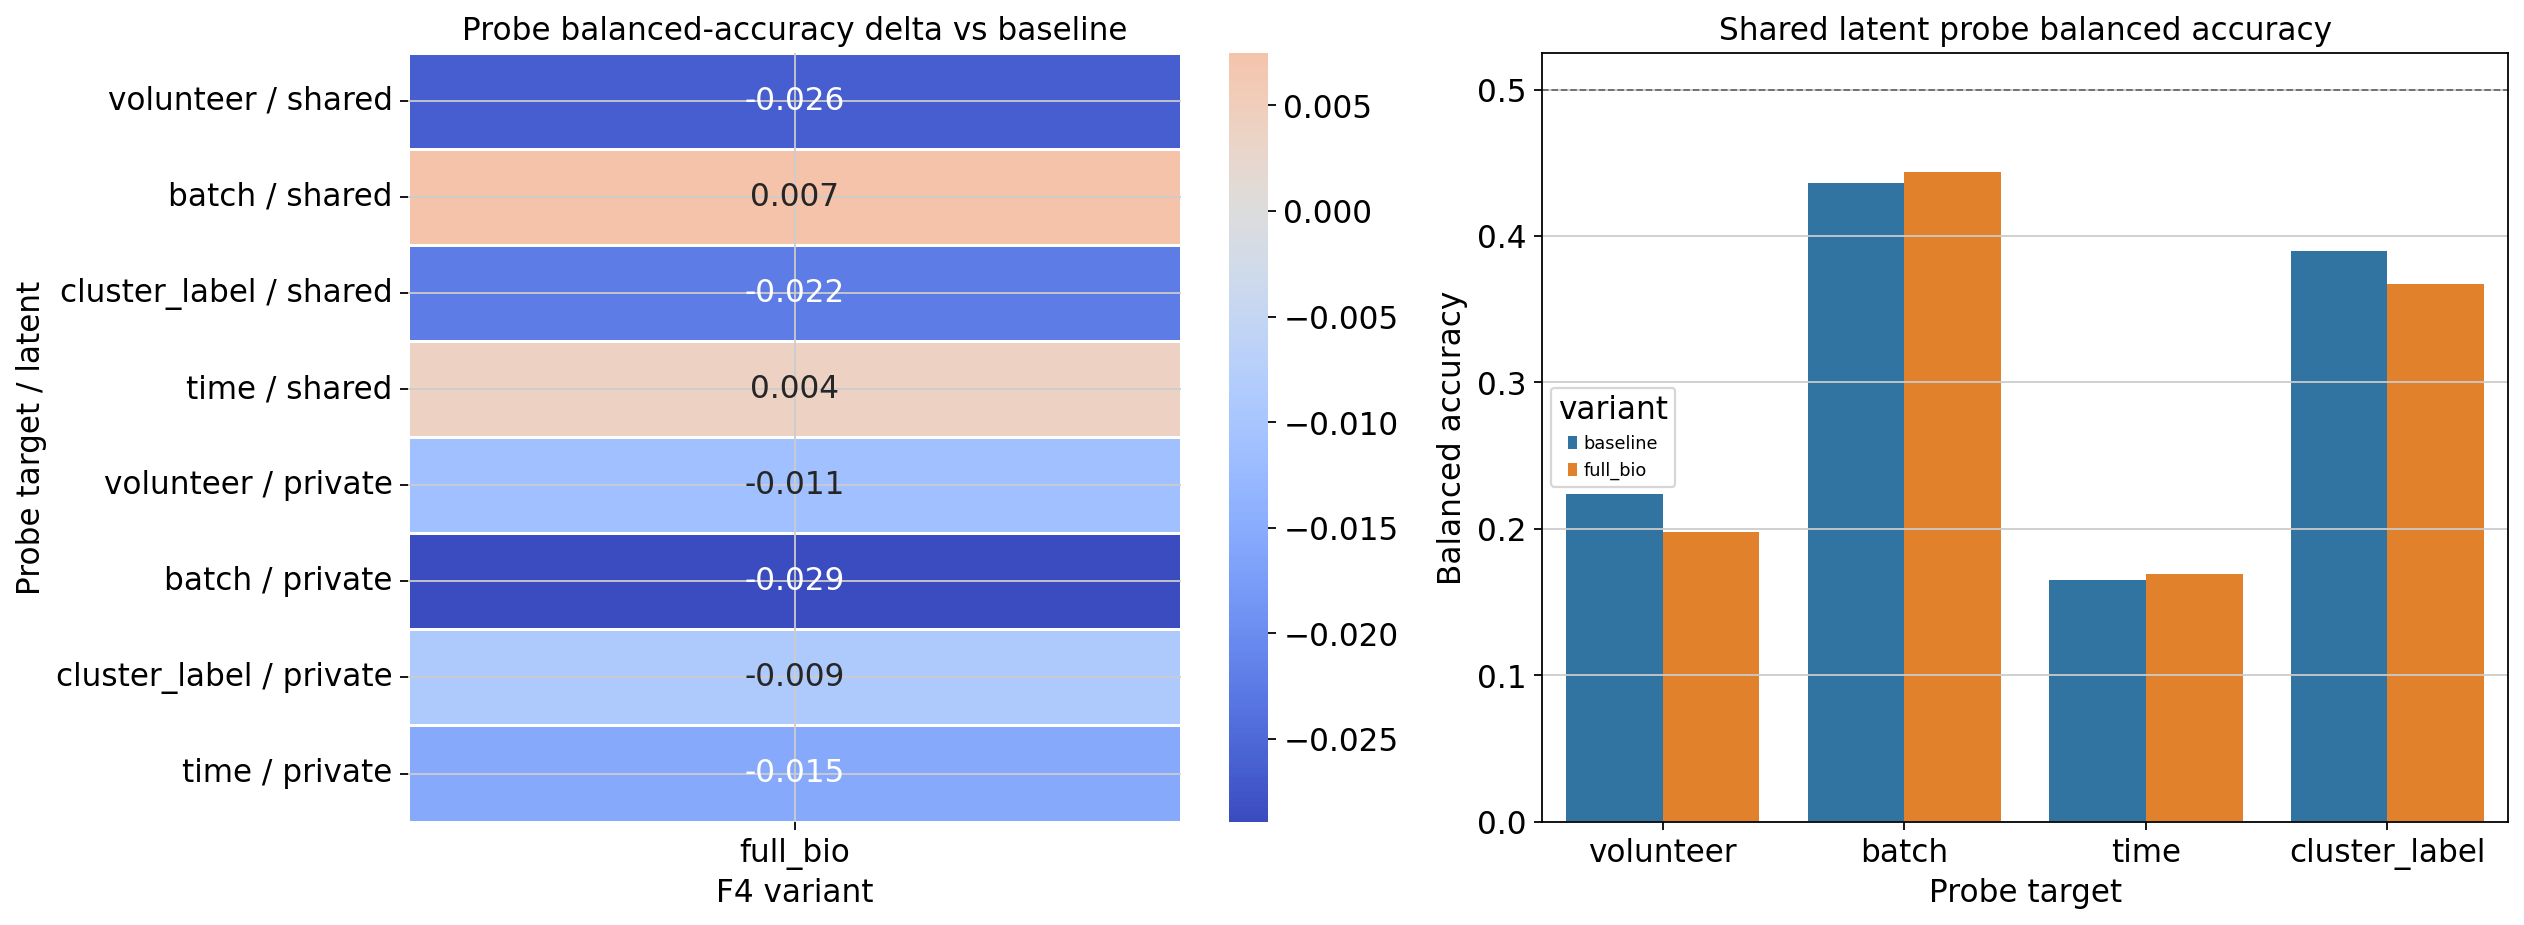

In [12]:
plot_df = probe_delta_df.copy()
plot_df["probe"] = plot_df["target"] + " / " + plot_df["latent"]

variant_order = [v for v in F4_VARIANTS_TO_RUN if v != "baseline"]
probe_order = [
    "volunteer / shared",
    "batch / shared",
    "cluster_label / shared",
    "time / shared",
    "volunteer / private",
    "batch / private",
    "cluster_label / private",
    "time / private",
]

_heat = (
    plot_df[plot_df["variant"].isin(variant_order)]
    .pivot_table(index="probe", columns="variant", values="delta_vs_baseline", aggfunc="first")
    .reindex(index=probe_order, columns=variant_order)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(
    _heat,
    annot=True,
    fmt=".3f",
    center=0,
    cmap="coolwarm",
    linewidths=0.5,
    ax=axes[0],
)
axes[0].set_title("Probe balanced-accuracy delta vs baseline")
axes[0].set_xlabel("F4 variant")
axes[0].set_ylabel("Probe target / latent")

_bar_df = plot_df[
    plot_df["target"].isin(["volunteer", "batch", "cluster_label", "time"])
    & (plot_df["latent"] == "shared")
].copy()
sns.barplot(
    data=_bar_df,
    x="target",
    y="balanced_accuracy",
    hue="variant",
    hue_order=F4_VARIANTS_TO_RUN,
    ax=axes[1],
)
axes[1].set_title("Shared latent probe balanced accuracy")
axes[1].set_xlabel("Probe target")
axes[1].set_ylabel("Balanced accuracy")
axes[1].axhline(0.5, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
axes[1].legend(title="variant", fontsize=8)
plt.tight_layout()
plt.show()


In [13]:
def _probe_metric(variant, target, latent, column="balanced_accuracy"):
    row = probe_delta_df[
        (probe_delta_df["variant"] == variant)
        & (probe_delta_df["target"] == target)
        & (probe_delta_df["latent"] == latent)
    ]
    if row.empty:
        return np.nan
    return float(row.iloc[0][column])


def _status(delta, lower_is_better):
    if not np.isfinite(delta):
        return "missing"
    if lower_is_better:
        if delta <= -0.02:
            return "improved"
        if delta >= 0.02:
            return "worse"
        return "similar"
    if delta < -0.05:
        return "degraded"
    if delta >= 0.02:
        return "higher"
    return "retained"

interpretation_rows = []
checks = [
    ("donor leakage from shared", "volunteer", "shared", True),
    ("batch leakage from shared", "batch", "shared", True),
    ("cell-type signal in shared", "cluster_label", "shared", False),
    ("time signal in shared", "time", "shared", False),
    ("donor signal in private", "volunteer", "private", False),
]
for variant in variant_order:
    for label, target, latent, lower_is_better in checks:
        bacc = _probe_metric(variant, target, latent, "balanced_accuracy")
        base = _probe_metric(variant, target, latent, "baseline_balanced_accuracy")
        delta = _probe_metric(variant, target, latent, "delta_vs_baseline")
        interpretation_rows.append({
            "variant": variant,
            "readout": label,
            "baseline_bacc": base,
            "variant_bacc": bacc,
            "delta": delta,
            "desired_direction": "lower" if lower_is_better else "same_or_higher",
            "status": _status(delta, lower_is_better),
        })

interpretation_df = pd.DataFrame(interpretation_rows)
display(
    interpretation_df.style.format({
        "baseline_bacc": "{:.3f}",
        "variant_bacc": "{:.3f}",
        "delta": "{:+.3f}",
    })
)

_focus = interpretation_df[interpretation_df["variant"] == DISPLAY_VARIANT]
print(f"Selected model: {DISPLAY_VARIANT}")
for _, row in _focus.iterrows():
    print(
        f"- {row['readout']}: {row['status']} "
        f"(delta {row['delta']:+.3f}; {row['variant_bacc']:.3f} vs baseline {row['baseline_bacc']:.3f})"
    )


,variant,readout,baseline_bacc,variant_bacc,delta,desired_direction,status
0,full_bio,donor leakage from shared,0.224,0.198,-0.026,lower,improved
1,full_bio,batch leakage from shared,0.436,0.444,+0.007,lower,similar
2,full_bio,cell-type signal in shared,0.390,0.367,-0.022,same_or_higher,retained
3,full_bio,time signal in shared,0.165,0.169,+0.004,same_or_higher,retained
4,full_bio,donor signal in private,0.264,0.253,-0.011,same_or_higher,retained


Selected model: full_bio
- donor leakage from shared: improved (delta -0.026; 0.198 vs baseline 0.224)
- batch leakage from shared: similar (delta +0.007; 0.444 vs baseline 0.436)
- cell-type signal in shared: retained (delta -0.022; 0.367 vs baseline 0.390)
- time signal in shared: retained (delta +0.004; 0.169 vs baseline 0.165)
- donor signal in private: retained (delta -0.011; 0.253 vs baseline 0.264)


In [14]:
# ── Training history summary ──────────────────────────────────────────────────
# Confirms whether early stopping fired and how each loss component evolved.
_h = f4_results[DISPLAY_VARIANT]["history"]
print(f"{'metric':45s}  {'first':>10}  {'final':>10}  {'drop':>10}  {'epochs':>7}")
print("-" * 90)
for _key in [
    "reconstruction_loss_train",
    "reconstruction_loss_validation",
    "elbo_train",
    "kl_local_train",
]:
    if _key in _h and len(_h[_key]) > 0:
        _arr = np.asarray(
            [float(np.asarray(v).ravel()[0]) for v in _h[_key].to_numpy().ravel()],
            dtype=float,
        )
        _ok = np.isfinite(_arr).all()
        print(
            f"{_key:45s}  {_arr[0]:10.1f}  {_arr[-1]:10.1f}"
            f"  {_arr[0] - _arr[-1]:10.1f}  {len(_arr):7d}  {'OK' if _ok else 'NaN!'}"
        )
    else:
        print(f"{_key:45s}  (not recorded)")


metric                                              first       final        drop   epochs
------------------------------------------------------------------------------------------
reconstruction_loss_train                             2.1         1.9         0.1      400  OK
reconstruction_loss_validation                       17.0        17.0        -0.0       40  OK
elbo_train                                            2.1         2.0         0.1      400  OK
kl_local_train                                        0.0         0.0        -0.0      400  OK


In [15]:
SAVE_SELECTED_MODEL = False
if SAVE_SELECTED_MODEL:
    model_spv.save(f"results/spvipes_bcells_time_f4_{DISPLAY_VARIANT}", overwrite=True)


In [16]:
# Hot-reload pl.py from source without reinstalling or restarting the kernel.
import importlib, importlib.util, sys, pathlib

_pl_path = pathlib.Path("/exports/para-lipg-hpc/mdmanurung/spVIPESmulti/src/spVIPESmulti/pl.py")
_spec = importlib.util.spec_from_file_location("spVIPESmulti.pl", _pl_path)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)

# Patch the already-imported package so spVIPESmulti.pl.training_curves picks up the fix.
sys.modules["spVIPESmulti.pl"] = _mod
import spVIPESmulti
spVIPESmulti.pl = _mod

# Verify the trainer's check_val_every_n_epoch so we know scaling is correct.
_t = getattr(model_spv, "trainer", None)
_cvene = getattr(_t, "check_val_every_n_epoch", "not found")
print(f"pl.py reloaded — check_val_every_n_epoch from trainer: {_cvene}")
print({k: len(v) for k, v in model_spv.history.items()})

pl.py reloaded — check_val_every_n_epoch from trainer: 10
{'train_loss': 400, 'elbo_train': 400, 'reconstruction_loss_train': 400, 'kl_local_train': 400, 'kl_global_train': 400, 'kl_divergence_private_group_0_train': 400, 'kl_divergence_poe_group_0_train': 400, 'kl_divergence_private_group_1_train': 400, 'kl_divergence_poe_group_1_train': 400, 'kl_divergence_private_group_2_train': 400, 'kl_divergence_poe_group_2_train': 400, 'kl_divergence_private_group_3_train': 400, 'kl_divergence_poe_group_3_train': 400, 'kl_divergence_private_group_4_train': 400, 'kl_divergence_poe_group_4_train': 400, 'kl_divergence_private_group_5_train': 400, 'kl_divergence_poe_group_5_train': 400, 'kl_divergence_private_group_6_train': 400, 'kl_divergence_poe_group_6_train': 400, 'disentangle_group_shared_loss_train': 400, 'disentangle_label_shared_loss_train': 400, 'disentangle_group_private_loss_train': 400, 'disentangle_label_private_loss_train': 400, 'disentangle_batch_shared_loss_train': 400, 'covariate_g

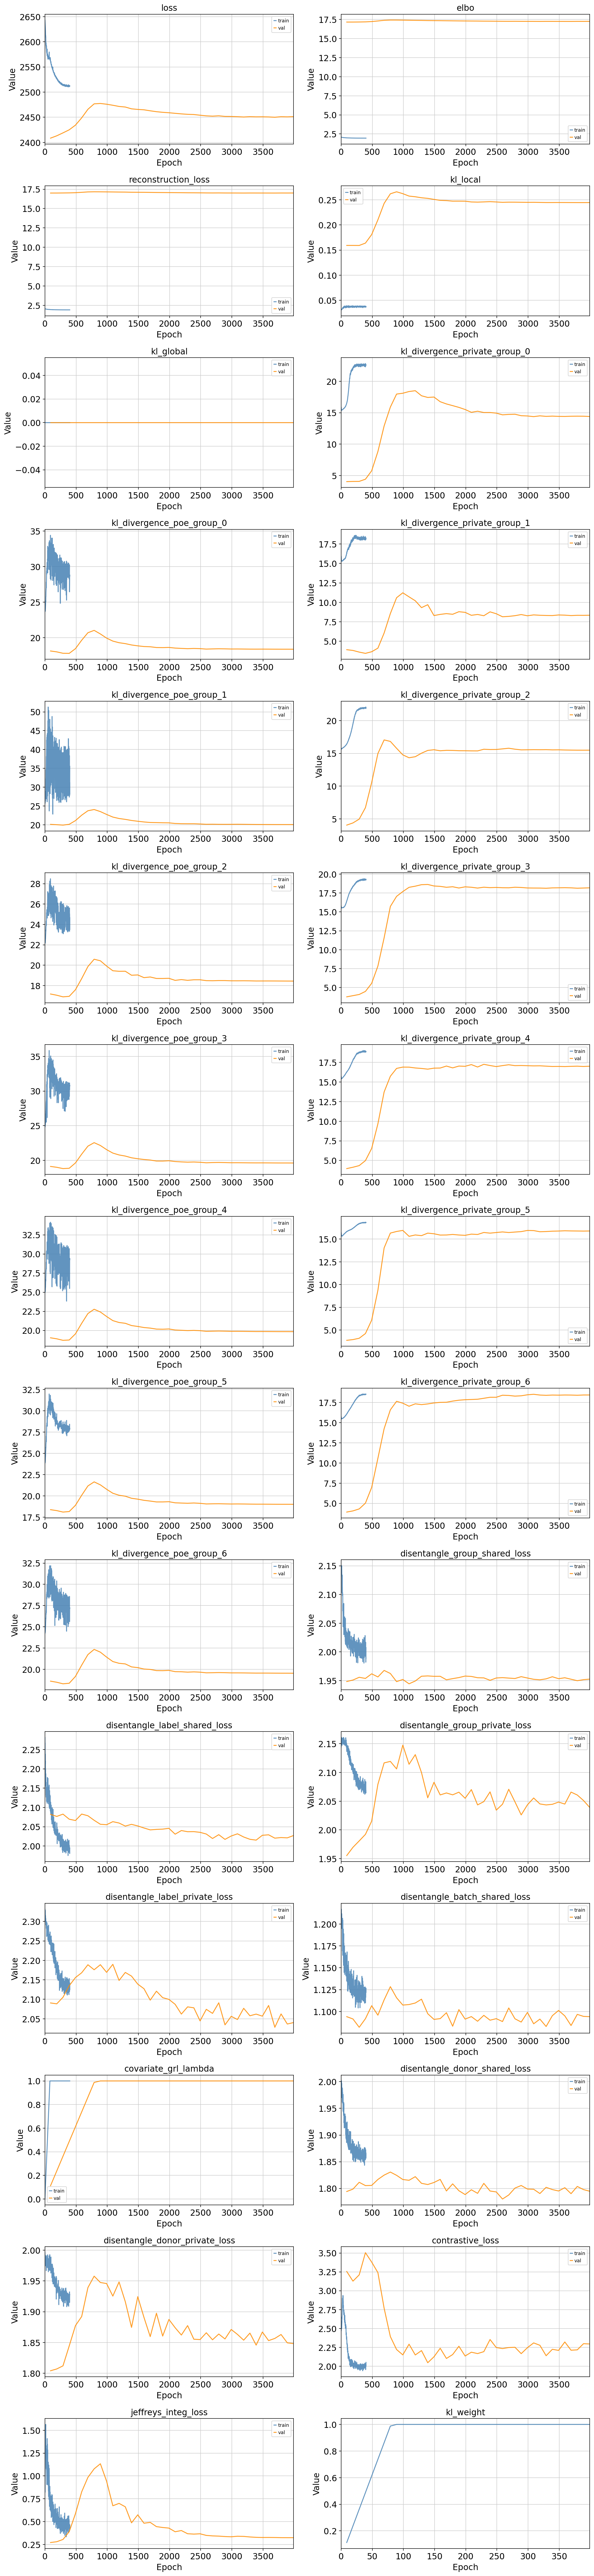

In [17]:
if model_spv is None:
    print("Selected model was not retained; rerun with KEEP_MODELS_IN_MEMORY=True for training curves.")
else:
    fig = spVIPESmulti.pl.training_curves(model_spv)


In [18]:
latents = f4_results[DISPLAY_VARIANT]["latents"]
spVIPESmulti.utils.store_latents(adata_spv, latents, group_indices_list)
print(f"Stored latents for {DISPLAY_VARIANT}")


Stored latents for full_bio


In [19]:
# Shared latent UMAP (all groups integrated):
spVIPESmulti.utils.compute_shared_umap(adata_spv, n_neighbors=20, min_dist=1)

AnnData object with n_obs × n_vars = 9978 × 36470
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'nCount_HTO', 'nFeature_HTO', 'batch', 'cellhashr_id', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_hemo', 'scdblfinder_score', 'scdblfinder_class', 'scran_size_factors', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'clonalProportion', 'clonalFrequency', 'cloneSize', 'barcode', 'IGH', 'cdr3_aa1', 'cdr3_nt1', 'IGLC', 'cdr3_nt2', 'has_bcr', 'NANP', 'NJunction', 'qc_keep', 'RNA.weight', 'ADT.weight', 'wsnn_res.1', 'seurat_clusters', 'MG_nn_res.0.1', 'MG_res.0.1', 'MG_nn_res.0.2', 'MG_res.0.2', 'MG_nn_res.0.3', 'MG_res.0.3', 'MG_nn_res.0.4', 'MG_res.0.4', 'MG_nn_res.0.5', 'MG_res.0.5', 'MG_nn_res.0.6', 'MG_res.0.6', 'MG_nn_res.0.7', 'MG_res.0.7', 'MG_nn_res.0.8', 'MG_res.0.8', 'MG_nn_res.0.9', 'MG_res.0.9', 'MG_nn_res.1', 'MG_res.1', 'MG_nn_res.1.1', 'MG_res.1.1', 'MG_nn_res.1.2', 'MG_res.1.2', 'MG_nn_res.1.3', 'MG_res.1.3', '

### Quantitative latent-space evaluation

Group mixing (higher = better): **iLISI**, **kBET**  
Label structure (higher = better): **k-NN purity**, **Leiden ARI**  
Label separation (lower = better): **cLISI**  
Private-latent group separation (higher = better): **silhouette**

In [20]:
# ── Integration report for selected F4 variant ─────────────────────────────
from spVIPESmulti.metrics import integration_report

z_shared = adata_spv.obsm["X_spVIPESmulti_shared"]
_groups_map = adata_spv.uns["groups_mapping"]

# Per-group private latents keyed by group name
z_private_dict = {
    str(_groups_map.get(gi, gi)): latents["private_reordered"][gi]
    for gi in range(len(group_indices_list))
}

_report = integration_report(
    z_shared,
    adata_spv.obs["time"].values,
    adata_spv.obs["cluster_label"].values,
    z_private_dict=z_private_dict,
    k=20,
)
print(f"Integration report for {DISPLAY_VARIANT}")
print(_report.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


Integration report for full_bio
           latent  ilisi  clisi  kbet  knn_purity  leiden_ari  silhouette
         z_shared  5.143  3.353 0.070       0.293       0.027         NaN
z_private (I1+14)    NaN    NaN   NaN         NaN         NaN      -0.101
 z_private (I1-1)    NaN    NaN   NaN         NaN         NaN      -0.228
z_private (I2+14)    NaN    NaN   NaN         NaN         NaN      -0.131
 z_private (I2-1)    NaN    NaN   NaN         NaN         NaN      -0.212
z_private (I3+14)    NaN    NaN   NaN         NaN         NaN      -0.164
 z_private (I3-1)    NaN    NaN   NaN         NaN         NaN      -0.197
 z_private (ZC-1)    NaN    NaN   NaN         NaN         NaN      -0.099


In [21]:
# ── Failure-mode audit ────────────────────────────────────────────────────────
from sklearn.neighbors import NearestNeighbors as _NNS
from sklearn.metrics import roc_auc_score as _auc

_K = 20
_labels = adata_spv.obs["cluster_label"].values
_nn = _NNS(n_neighbors=_K + 1).fit(z_shared)
_, _idx = _nn.kneighbors(z_shared)
_idx = _idx[:, 1:]

# Per-cell-type k-NN purity
_purity = np.array([((_labels[_idx[i]] == _labels[i]).mean()) for i in range(len(_labels))])
_purity_df = (
    pd.DataFrame({"cluster_label": _labels, "knn_purity": _purity})
    .groupby("cluster_label")["knn_purity"]
    .agg(["mean", "std", "count"])
    .sort_values("mean")
)
print("Per-cell-type k-NN purity (k=20) in z_shared — lower = harder to separate:")
print(_purity_df.to_string(float_format=lambda x: f"{x:.3f}"))

# One-vs-rest AUROC per shared dimension
_Z = z_shared
_cell_types = sorted(np.unique(_labels))
_auroc = np.full((len(_cell_types), _Z.shape[1]), np.nan)
for _ci, _ct in enumerate(_cell_types):
    _y = (_labels == _ct).astype(int)
    if _y.sum() < 5 or (1 - _y).sum() < 5:
        continue
    for _di in range(_Z.shape[1]):
        try:
            _auroc[_ci, _di] = _auc(_y, _Z[:, _di])
        except Exception:
            pass

_auroc_df = pd.DataFrame(
    _auroc, index=_cell_types,
    columns=[f"shared_{i}" for i in range(_Z.shape[1])],
)
_best_dim_per_type = _auroc_df.max(axis=1).sort_values()
print("\nBest shared-dim one-vs-rest AUROC per cell type (closer to 1.0 = more separable):")
print(_best_dim_per_type.to_string(float_format=lambda x: f"{x:.3f}"))

# Island / outlier check: antigen × batch breakdown per cell type
print("\nCell count by cluster_label × antigen_specific (check for island-causing confounds):")
print(
    pd.crosstab(
        adata_spv.obs["cluster_label"],
        adata_spv.obs["antigen_specific"],
    ).to_string()
)

Per-cell-type k-NN purity (k=20) in z_shared — lower = harder to separate:
                 mean   std  count
cluster_label                     
Plasmablast     0.061 0.145    356
Pre-Plasmablast 0.078 0.075    637
Activated MZ    0.105 0.085    772
Transitional    0.145 0.133    434
Naïve           0.167 0.132    687
Classical       0.228 0.136   1653
Activated       0.335 0.150   2284
Atypical        0.459 0.158   3155

Best shared-dim one-vs-rest AUROC per cell type (closer to 1.0 = more separable):
Pre-Plasmablast   0.561
Classical         0.565
Activated MZ      0.578
Atypical          0.613
Activated         0.617
Plasmablast       0.659
Naïve             0.776
Transitional      0.787

Cell count by cluster_label × antigen_specific (check for island-causing confounds):
antigen_specific  CRXV  NANP  Njunc
cluster_label                      
Activated         1609   470    205
Activated MZ       468   254     50
Atypical          2242   685    228
Classical         1142   295    21

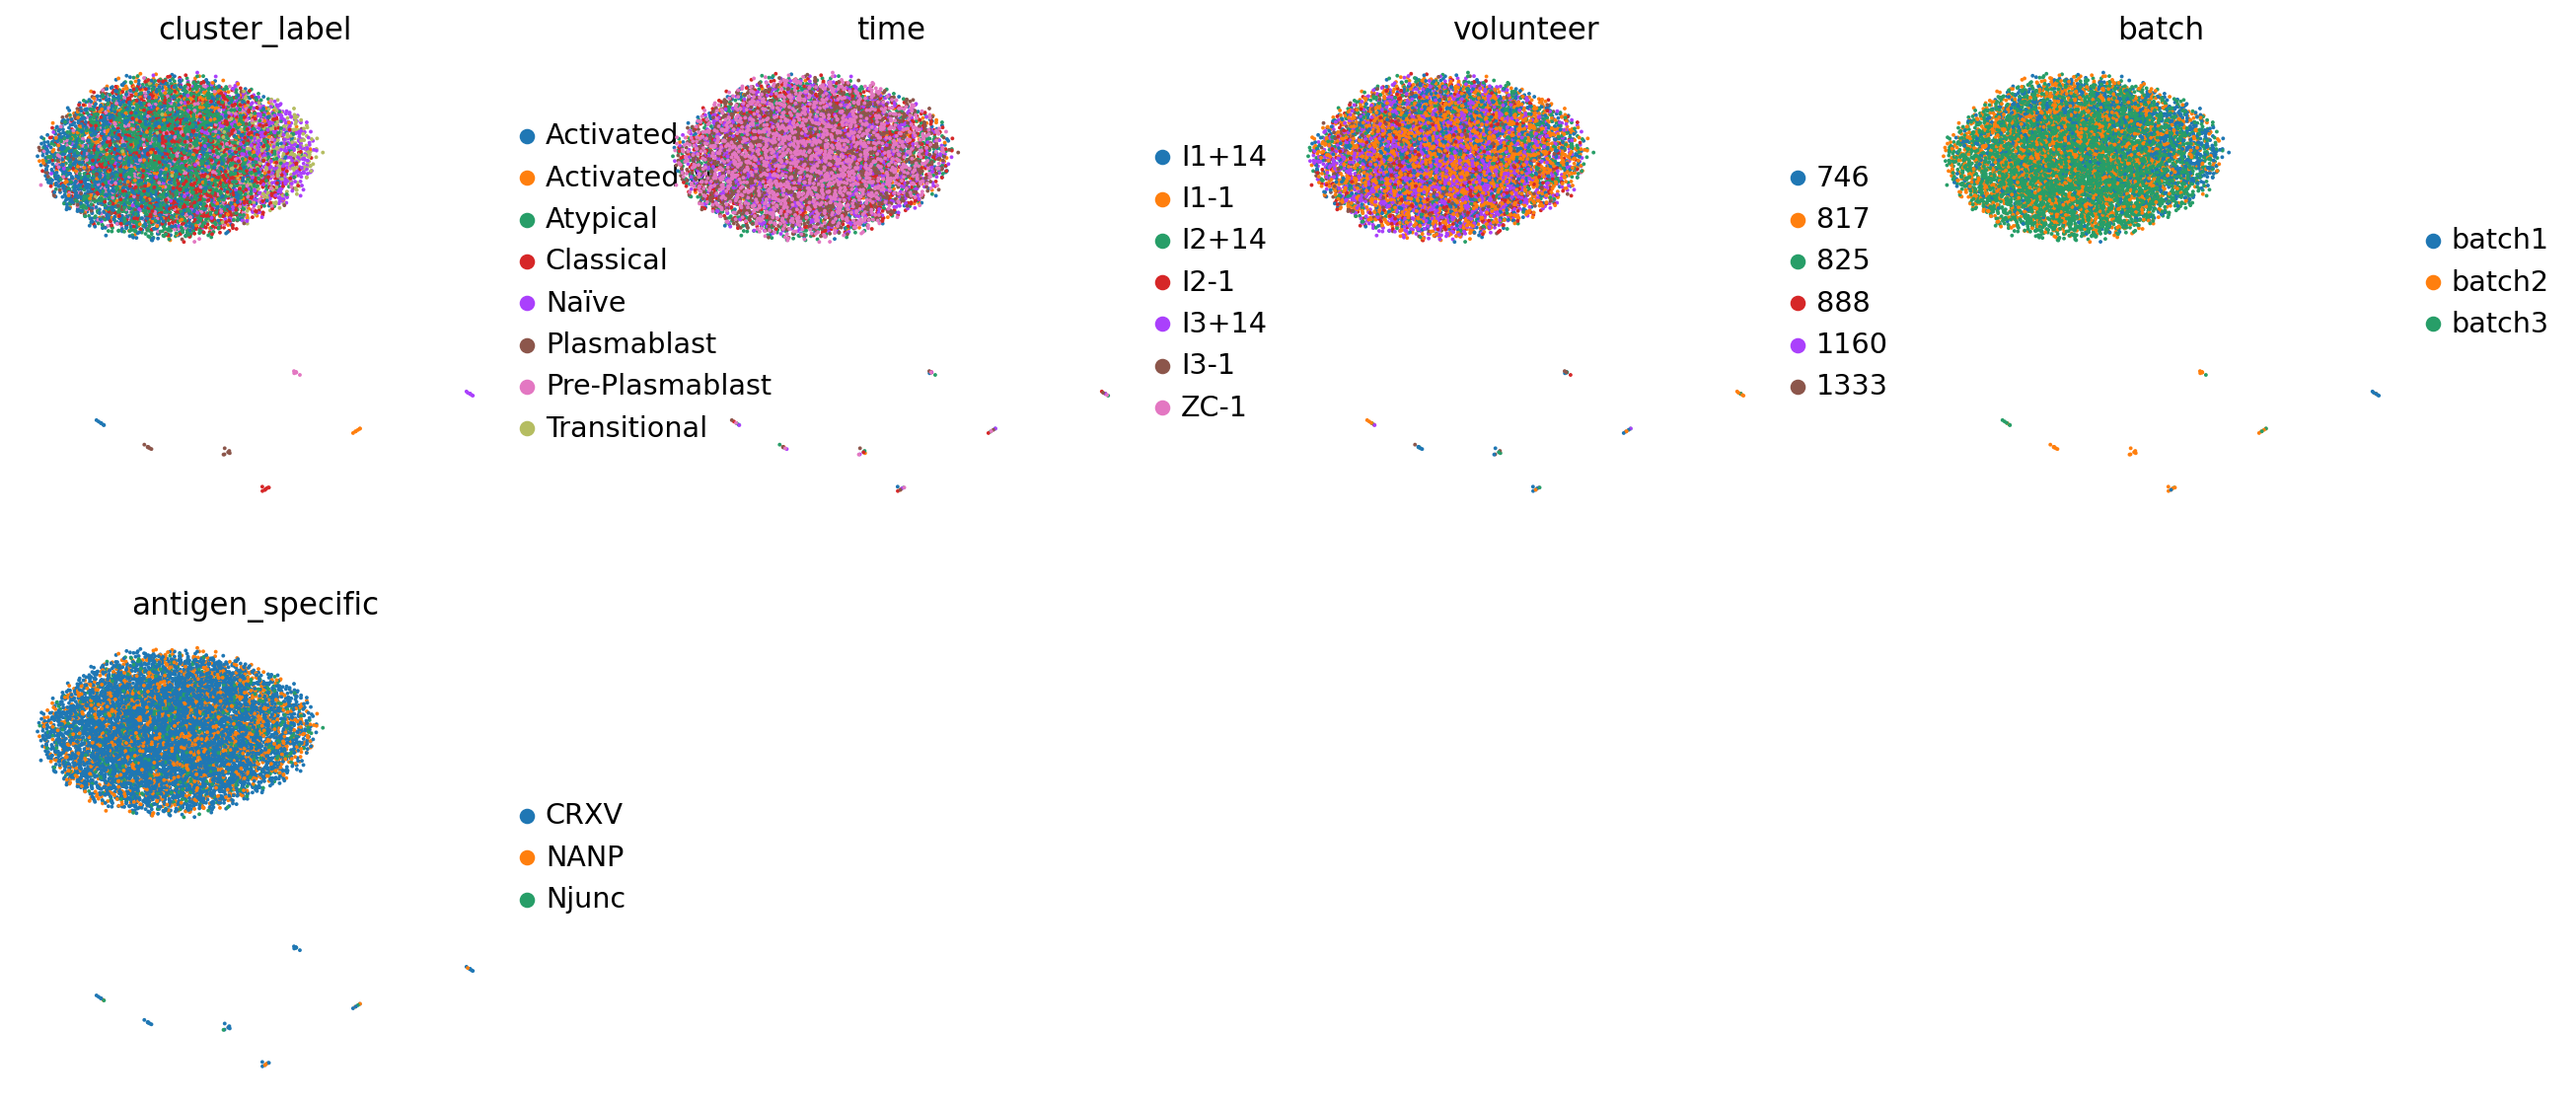

In [22]:
spVIPESmulti.pl.umap_shared(
    adata_spv,
    color=["cluster_label", "time", "volunteer", "batch", "antigen_specific"],
)


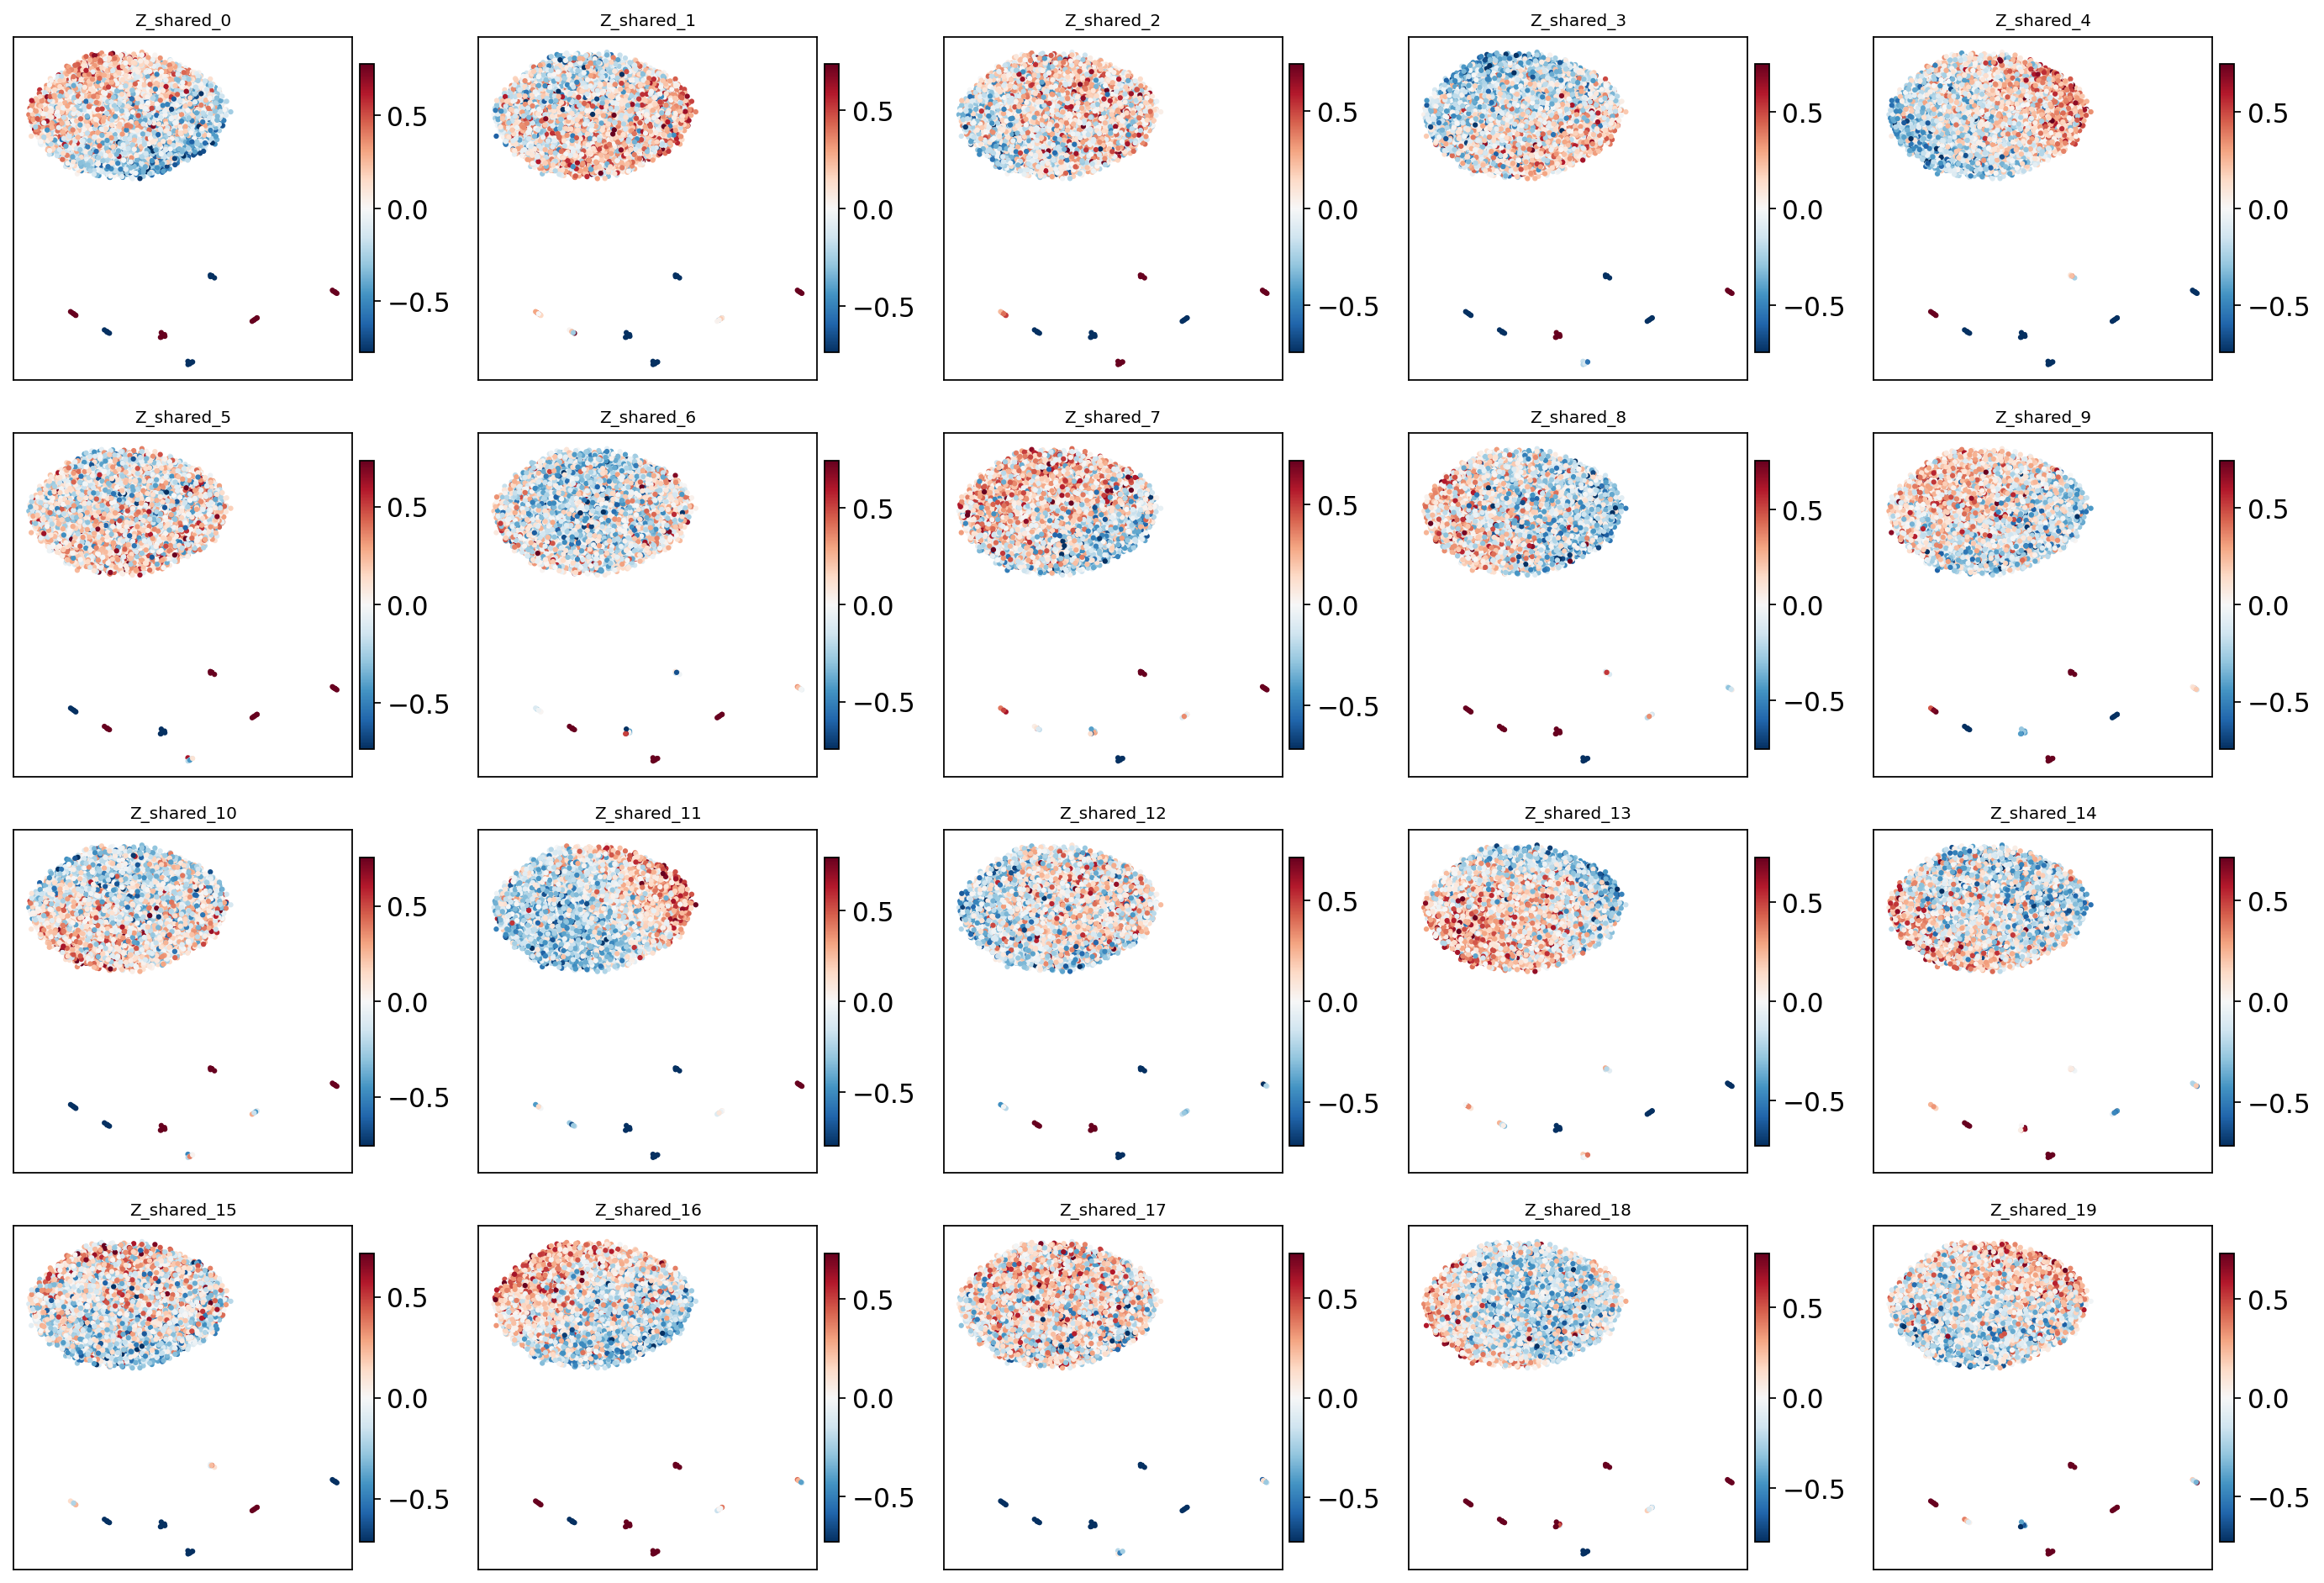

In [23]:
fig = spVIPESmulti.pl.plot_latent_dims_in_umap(adata_spv, "X_spVIPESmulti_shared")

In [24]:
import datetime
print(f"Run date      : {datetime.date.today()}")
print(f"F4 variants   : {F4_VARIANTS_TO_RUN}")
print(f"Display model : {DISPLAY_VARIANT}")
print(f"spVIPESmulti  : {spVIPESmulti.__version__}")
print(f"scvi-tools    : {scvi.__version__}")
print(f"scanpy        : {sc.__version__}")
print(f"torch         : {torch.__version__}")
print(f"accelerator   : {TRAIN_ACCELERATOR}, devices={TRAIN_DEVICES}, precision={TRAIN_PRECISION}")


Run date      : 2026-05-11
F4 variants   : ['baseline', 'full_bio']
Display model : full_bio
spVIPESmulti  : 1.0.0
scvi-tools    : 1.4.2
scanpy        : 1.12.1
torch         : 2.11.0+cu128
accelerator   : gpu, devices=1, precision=32-true
